# 1. Libraries & Dataset Loading

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from xgboost import XGBRegressor
from xgboost import plot_importance, plot_tree
from lightgbm import LGBMRegressor 
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
df_train = pd.read_csv("C:\\Users\\İlyas\\OneDrive\\Belgeler\\veri setleri ve vs code çalışmaları\\Predict Calorie Expenditure\\train.csv")
df_test = pd.read_csv("C:\\Users\\İlyas\\OneDrive\\Belgeler\\veri setleri ve vs code çalışmaları\\Predict Calorie Expenditure\\test.csv")

# 2. Exploratory Data Analysis (EDA)¶

# - 2.1 Data Overview

In [4]:
# Previewing the Data

df_train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [5]:
# Dataset Shape

df_train.shape

(750000, 9)

In [6]:
# Dataset Information

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [7]:
# Missing Data Inspection

df_train.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [8]:
# Descriptive Statistics

df_train.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [9]:
# Correlation Matrix

cor = df_train.corr(numeric_only=True)
cor

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
id,1.000000,0.002330,0.000101,0.000524,0.001647,0.001092,0.001612,0.001148
Age,0.002330,1.000000,0.011975,0.073690,0.015656,0.017037,0.030275,0.145683
Height,0.000101,0.011975,1.000000,0.957967,-0.029936,-0.013234,-0.034641,-0.004026
Weight,0.000524,0.073690,0.957967,1.000000,-0.020845,-0.002384,-0.023717,0.015863
Duration,0.001647,0.015656,-0.029936,-0.020845,1.000000,0.875327,0.903066,0.959908
Heart_Rate,0.001092,0.017037,-0.013234,-0.002384,0.875327,1.000000,0.795972,0.908748
Body_Temp,0.001612,0.030275,-0.034641,-0.023717,0.903066,0.795972,1.000000,0.828671
Calories,0.001148,0.145683,-0.004026,0.015863,0.959908,0.908748,0.828671,1.000000


In [10]:
# Column Names

df_train.columns

Index(['id', 'Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

In [11]:
sex_counts = df_train["Sex"].value_counts()
sex_counts

Sex
female    375721
male      374279
Name: count, dtype: int64

# - 2.2 Data Visualization

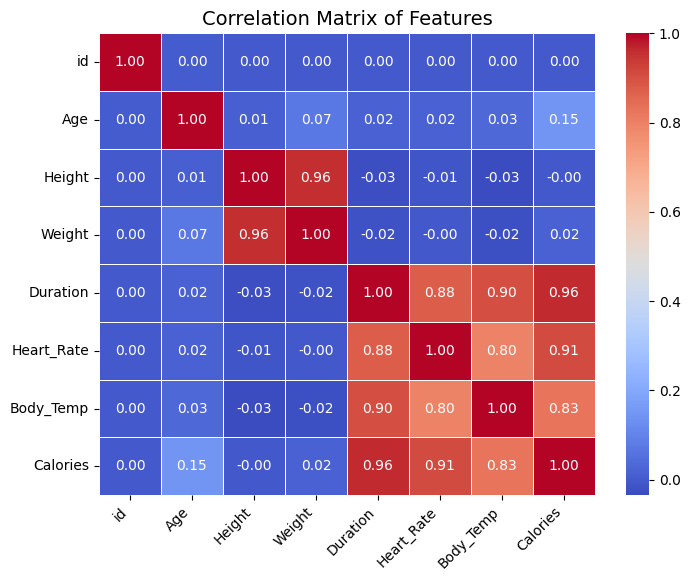

In [12]:
# Correlation Matrix Heatmap

plt.figure(figsize = (8,6))
sns.heatmap(data = cor, annot = True, cmap = "coolwarm", linewidths = 0.5, fmt='.2f', annot_kws={'size': 10})
plt.title("Correlation Matrix of Features", fontsize=14)
plt.xticks(rotation=45, ha='right')   
plt.yticks(rotation=0)   
plt.show()

Text(0.5, 1.0, 'Gender Distribution')

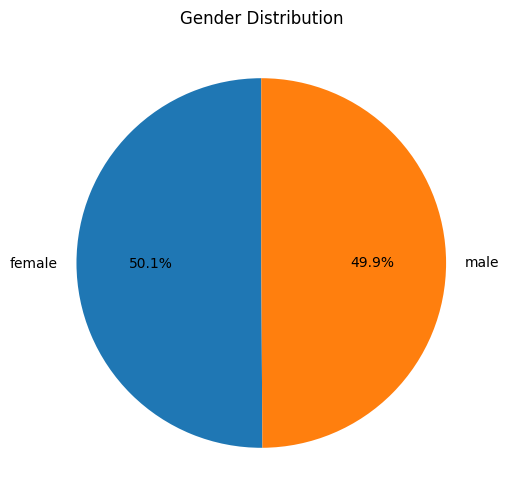

In [13]:
# Gender Distribution

plt.figure(figsize = (8,6))
plt.pie(sex_counts, labels = sex_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Gender Distribution")

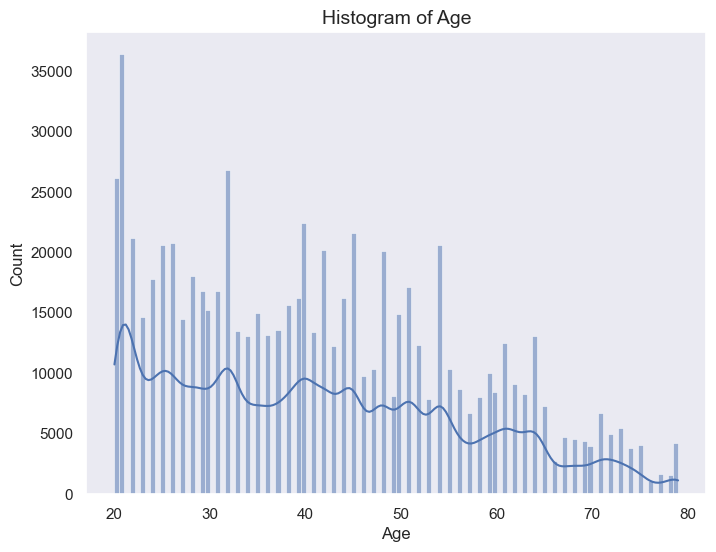

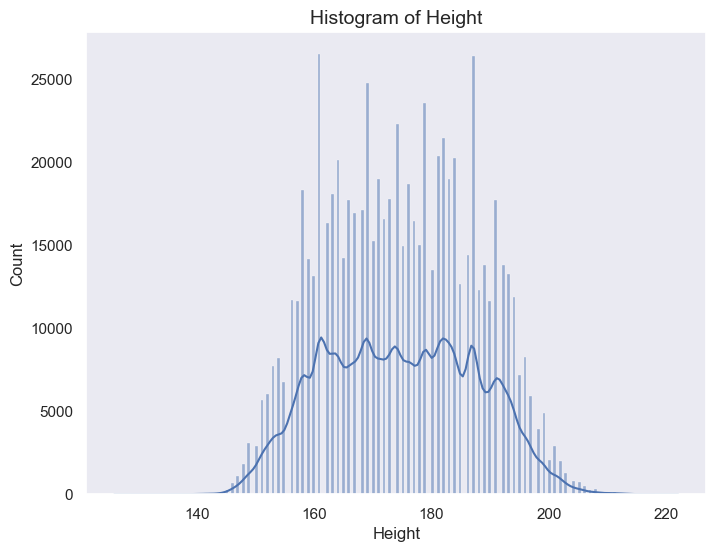

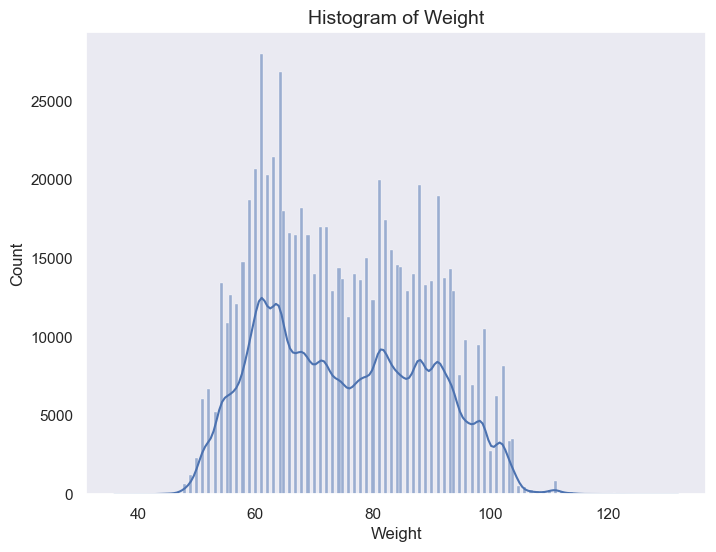

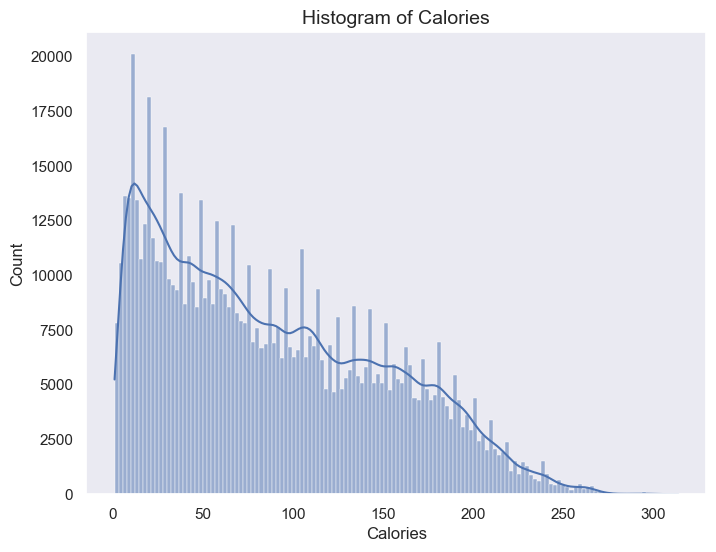

In [14]:
#  Distribution of Numerical Features

hist_vz = ["Age", "Height", "Weight", "Calories"]

for i in hist_vz:
    plt.figure(figsize = (8,6))
    sns.set(style="dark")
    sns.histplot(data = df_train, x =i, kde = True);
    plt.title(f"Histogram of {i}", fontsize=14)

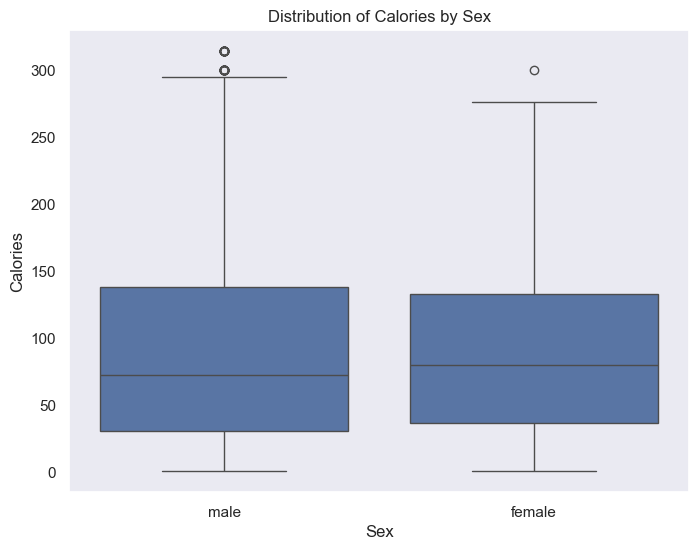

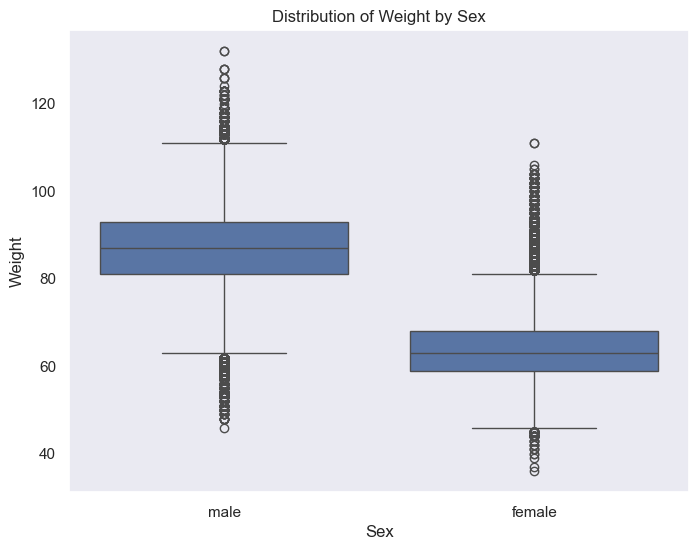

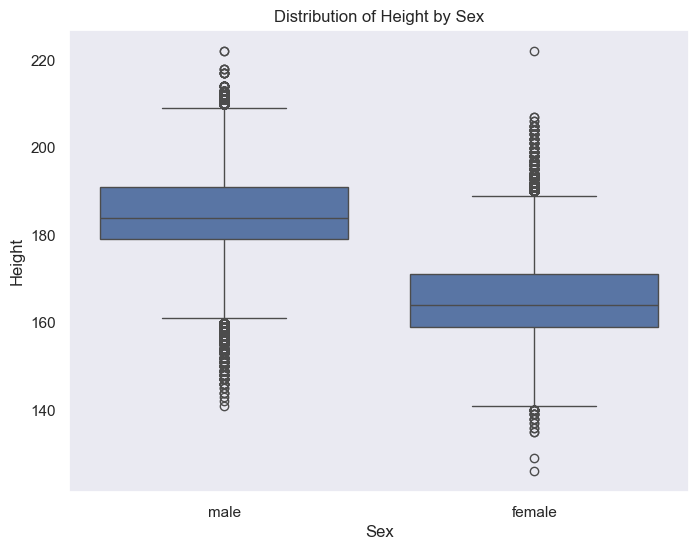

In [15]:
# Boxplot Analysis of Numerical Features by Sex

box_vz = ["Calories", "Weight", "Height"]

for n in box_vz:
    plt.figure(figsize =(8,6))
    sns.boxplot(data= df_train, x="Sex", y =n)
    plt.title(f"Distribution of {n} by Sex")

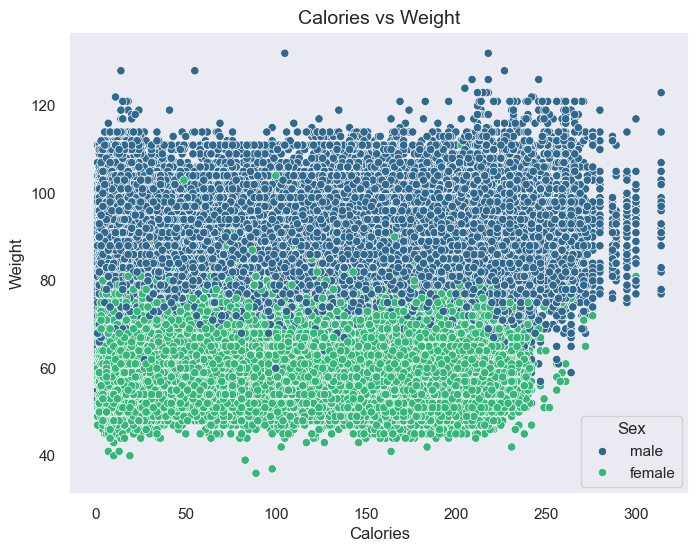

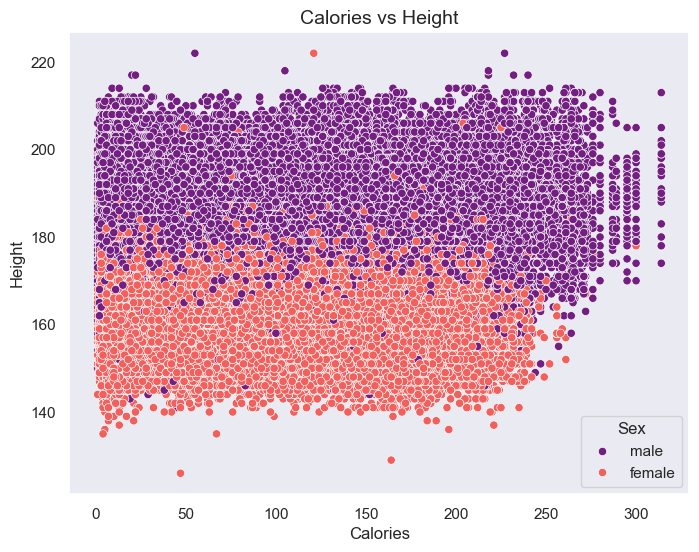

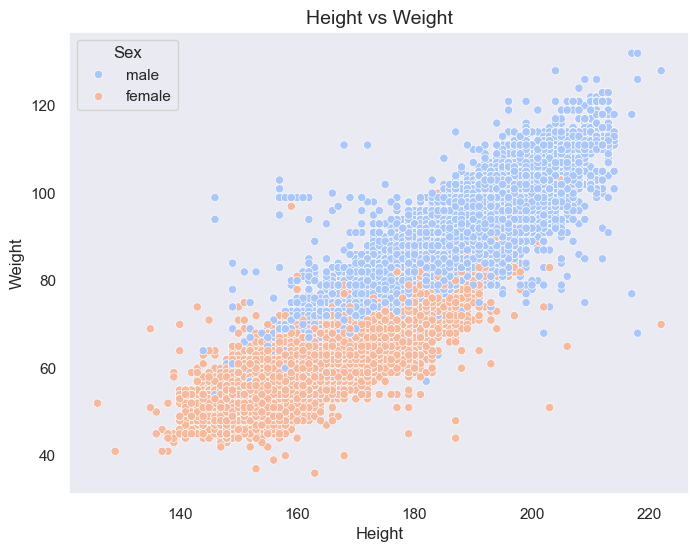

In [16]:
# Scatter Plots of Feature Relationships by Sex

scatter_vz = [("Calories", "Weight"), ("Calories", "Height"), ("Height", "Weight")]
palet = ["viridis", "magma", "coolwarm"]

for (x_colmn, y_colmn), color in zip(scatter_vz, palet):
    plt.figure(figsize =(8,6))
    sns.scatterplot(data= df_train, x= x_colmn, y= y_colmn, hue="Sex", palette = color)
    plt.title(f"{x_colmn} vs {y_colmn}", fontsize=14)
    plt.show()

# - 2.3 Feature Engineering

In [17]:
test_id = df_test["id"].copy()
def feature(df):

    df["Sex"] = df["Sex"].map({"male": 1, "female": 0})
    df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)
    df.drop("id", axis=1, errors = "ignore")
    if "Heart_Rate" in df.columns and "Duration" in df.columns:
        df["Intensity"] = df["Heart_Rate"] * df["Duration"]
    
    return df

In [18]:
df_trian = feature(df_train)
df_test = feature(df_test)

In [19]:
df_train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Intensity
0,0,1,36,189.0,82.0,26.0,101.0,41.0,150.0,22.955684,2626.0
1,1,0,64,163.0,60.0,8.0,85.0,39.7,34.0,22.582709,680.0
2,2,0,51,161.0,64.0,7.0,84.0,39.8,29.0,24.690405,588.0
3,3,1,20,192.0,90.0,25.0,105.0,40.7,140.0,24.414062,2625.0
4,4,0,38,166.0,61.0,25.0,102.0,40.6,146.0,22.136740,2550.0


In [20]:
df_test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,Intensity
0,750000,1,45,177.0,81.0,7.0,87.0,39.8,25.854639,609.0
1,750001,1,26,200.0,97.0,20.0,101.0,40.5,24.250000,2020.0
2,750002,0,29,188.0,85.0,16.0,102.0,40.4,24.049344,1632.0
3,750003,0,39,172.0,73.0,20.0,107.0,40.6,24.675500,2140.0
4,750004,0,30,173.0,67.0,16.0,94.0,40.5,22.386314,1504.0


# 3. Modeling

In [21]:
# Splitting features and target (X, y)

X = df_train.drop("Calories", axis=1)
y = df_train["Calories"]

# Train-validation split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

## - 3.1 Model 1: XGBoost Regressor

In [22]:
#  XGBoost regressor model

xgb_model = XGBRegressor(
     n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,        
    reg_lambda=1.0,            
    reg_alpha=0.5,            
    subsample=0.8,           
    colsample_bytree=0.8,    
    min_child_weight=10,      
    gamma=0.2,               
    max_delta_step=0,      
    grow_policy='depthwise',
    tree_method='hist',        
    objective='reg:squarederror',
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

In [23]:
# Model Training

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.2, grow_policy='depthwise',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=0, max_depth=7,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [30]:
xgb_pred = xgb_model.predict(X_val)
xgb_pred_clipped = np.maximum(0, xgb_pred)
rmsle = np.sqrt(mean_squared_log_error(y_val, xgb_pred_clipped))
print(f"RMSLE: {rmsle}")

RMSLE: 0.061285839101845145


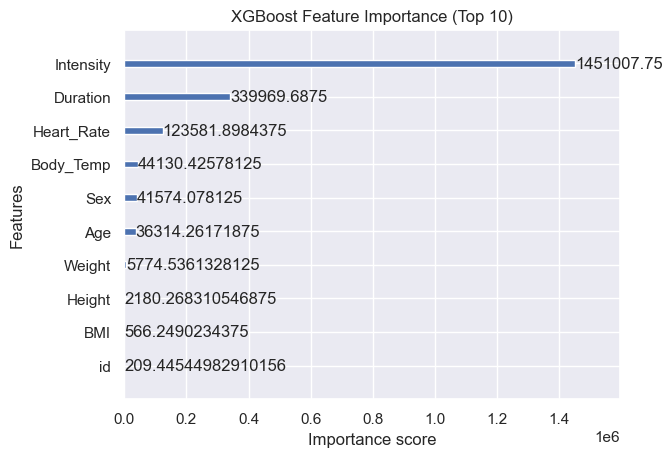

In [31]:
plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.title("XGBoost Feature Importance (Top 10)")
plt.show()

## -3.2 Model 2: LightGBM Regressor

In [24]:
lgbm_model = lgbm_model = LGBMRegressor()

In [25]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 10
[LightGBM] [Info] Start training from score 88.298465


LGBMRegressor()

In [26]:
lgbm_pred = lgbm_model.predict(X_val)
lgbm_pred_clipped = np.maximum(0, lgbm_pred)
rmsle = np.sqrt(mean_squared_log_error(y_val, lgbm_pred_clipped))
print(f"RMSLE: {rmsle}")

RMSLE: 0.06844910865411377


## - 3.3 Model 3: CatBoost Regressor

In [36]:
#  Model Initialization

cat_model = CatBoostRegressor(
    depth=8,
    learning_rate=0.035,
    iterations=3500,
    loss_function="RMSE",     
    verbose=0
)

In [37]:
cat_model.fit(X_train, y_train)

In [38]:
# Prediction & Evaluation

cat_pred = cat_model.predict(X_val)
cat_pred_nonneg = np.clip(cat_pred, a_min=0, a_max=None)   
rmsle = np.sqrt(mean_squared_log_error(y_val, cat_pred_nonneg))
print(f"RMSLE: {rmsle}")

RMSLE: 0.06043179840614843


In [39]:
# CatBoost ile test seti tahmini
cat_test_pred = np.maximum(0, cat_model.predict(df_test))

# Submission DataFrame oluşturma
submission = pd.DataFrame({
    "id": test_id,
    "Calories_Burned": cat_test_pred
})

# CSV olarak kaydetme
submission.to_csv("catboost_submission.csv", index=False)

print("Submission file created: catboost_submission.csv")


Submission file created: catboost_submission.csv
